1. Data Collection & Dataset Overview

In this study, I investigate the long-term investment performance of luxury and mid-range watches in comparison to global macroeconomic indicators between 2005 and 2026. I selected this topic because of my growing interest in "alternative assets" and wealth management. In the modern financial landscape, luxury timepieces have transitioned from being mere accessories to significant stores of value, often behaving differently than traditional stock markets or currencies. My goal is to analyze whether these physical assets provide a hedge against inflation or follow broader market trends.

Data Sources:
Historical Watch Market Data: A comprehensive dataset containing monthly and annual price records for various watch models (categorized as Entry-Level, Mid-Range, and Luxury). The data includes primary and secondary market valuations in USD.
Global Financial Indicators (Finance.csv): Key macroeconomic data including inflation rates (CPI), interest rates, and major stock market indices to represent the broader economic environment.
Market Supply & Demand Metrics: Historical data points reflecting brand-specific production trends and collector demand to control for brand equity shocks.

Dataset Characteristics:
The final merged dataset is a structured Time-Series & Panel Data containing the following key variables:

Name: Specific watch model (e.g., Rolex Submariner, Omega Speedmaster).
Category: Categorical variable segmenting watches into Luxury, Mid-Range, and Entry-Level based on their mean price points.
Year: Temporal variable ranging from 2005 to 2026.
Value: The price of the asset in USD.
Pct_Increase: A calculated variable representing cumulative growth since the 2005 baseline to normalize different price levels.
Indicator_Name: Macroeconomic benchmarks (e.g., Inflation, GDP Growth, or S&P 500 equivalent).
CAGR (Compound Annual Growth Rate): A derived metric used in the final analysis to compare the smoothed annual yield of watches versus financial assets.

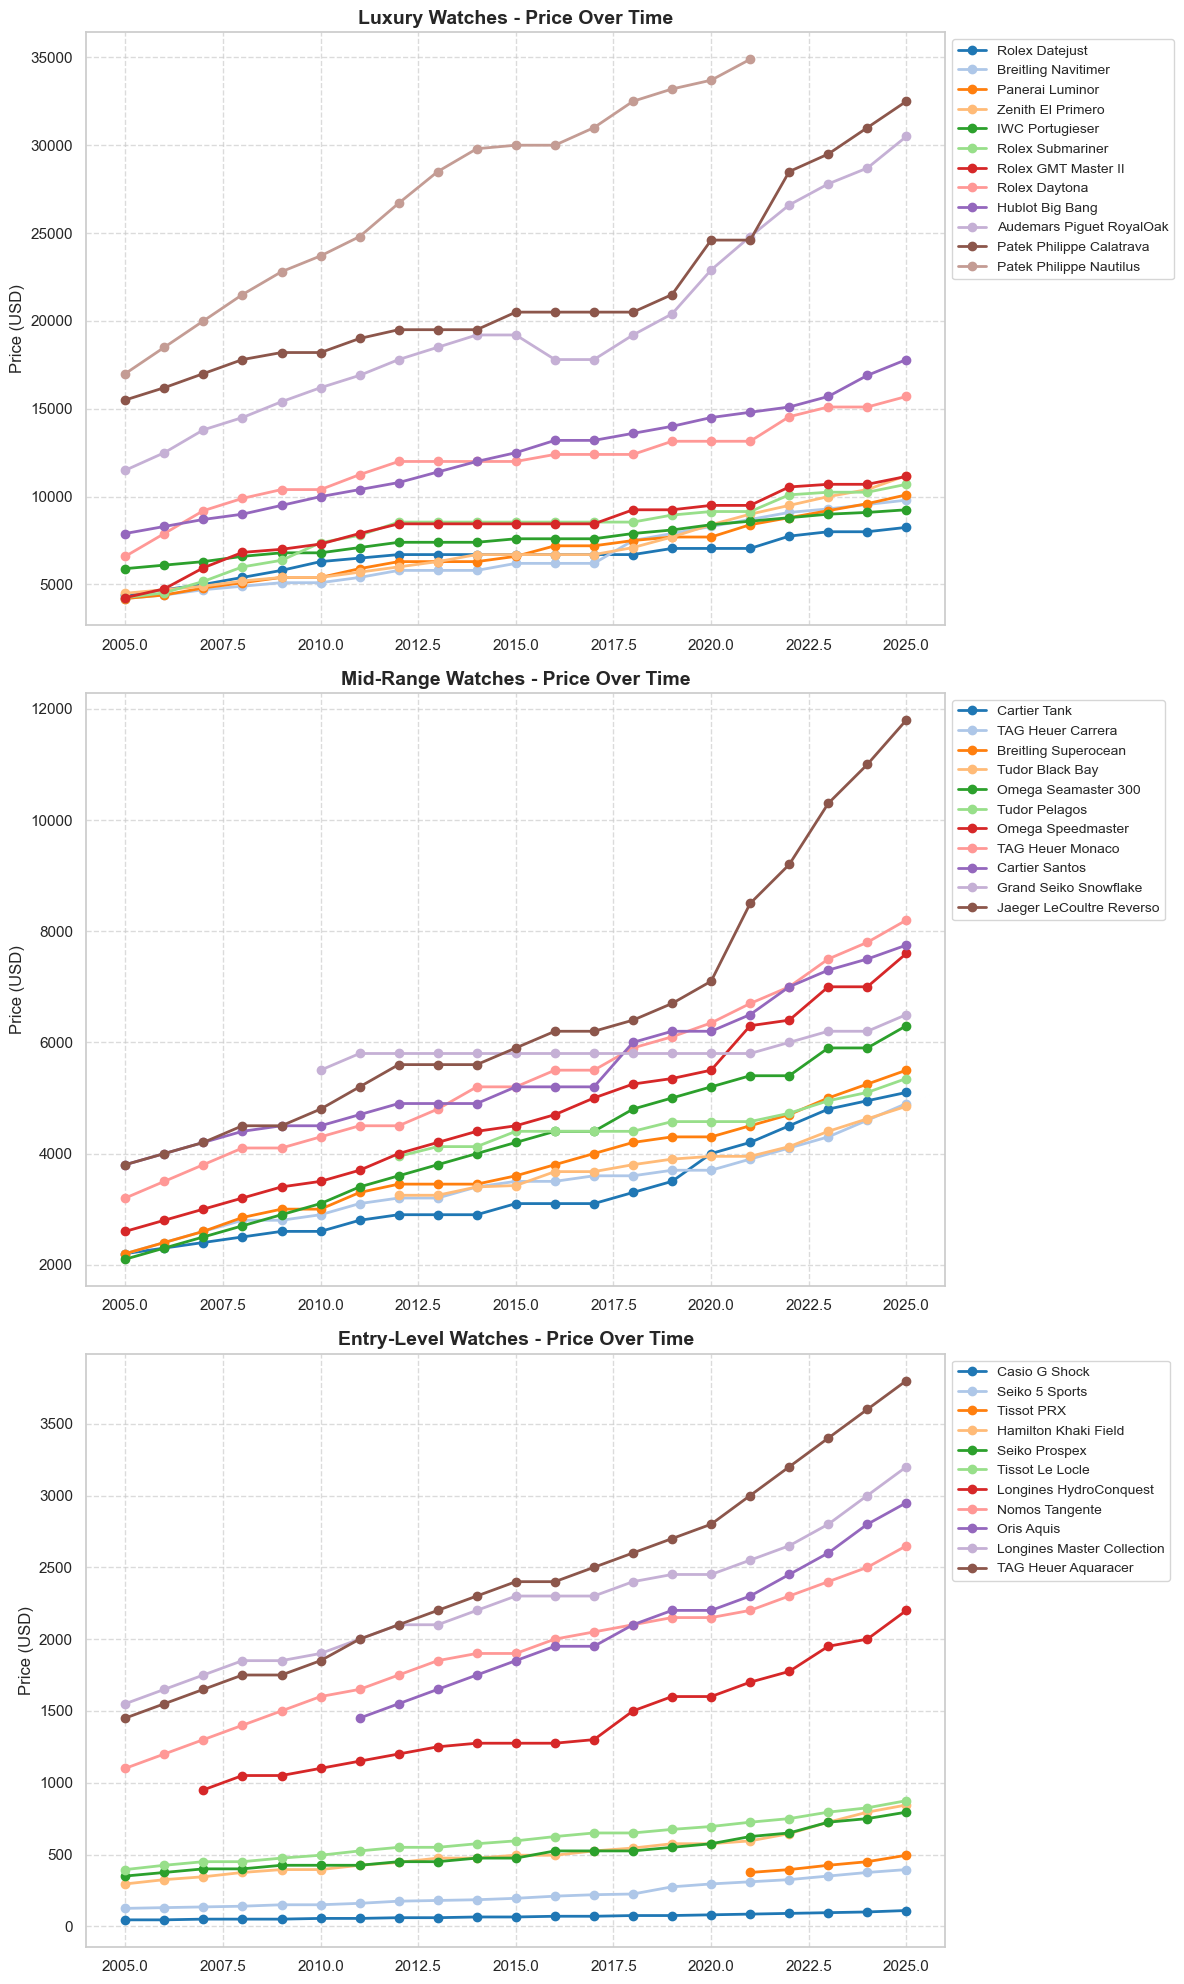

/var/folders/rl/hkspg_7n00n1nf1kmwmml9m00000gn/T/ipykernel_31530/3736403611.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  finance_colors = plt.cm.get_cmap('Dark2', len(indicators))


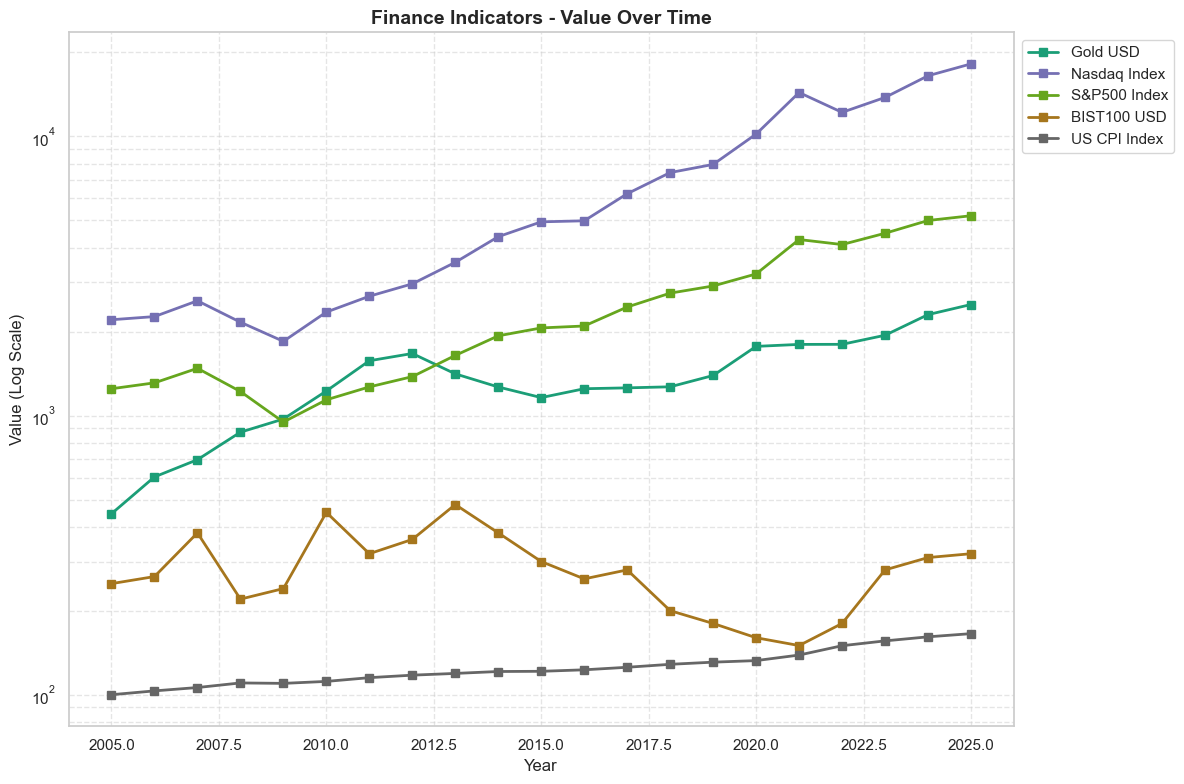

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- WATCHES  ---
try:
    df_watches = pd.read_csv('saat_verileri_son.csv')
    df_watches = df_watches[df_watches['Name'] != 'Richard_Mille_RM011']

    avg_prices = df_watches.groupby('Name')['Value'].mean().sort_values()

    n = len(avg_prices)
    entry_watches = avg_prices.iloc[:n//3].index
    mid_watches = avg_prices.iloc[n//3:2*n//3].index
    luxury_watches = avg_prices.iloc[2*n//3:].index

    fig, axes = plt.subplots(3, 1, figsize=(12, 20))

    
    colors = plt.cm.tab20.colors 

    def plot_with_distinct_colors(ax, watch_list, title):
        
        for i, watch in enumerate(watch_list):
            data = df_watches[df_watches['Name'] == watch]
            
            color = colors[i % len(colors)] 
            ax.plot(data['Year'], data['Value'], label=watch.replace('_', ' '), 
                    marker='o', color=color, linewidth=2)
        
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_ylabel('Price (USD)')
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small')
        ax.grid(True, linestyle='--', alpha=0.7)

    plot_with_distinct_colors(axes[0], luxury_watches, 'Luxury Watches - Price Over Time')
    plot_with_distinct_colors(axes[1], mid_watches, 'Mid-Range Watches - Price Over Time')
    plot_with_distinct_colors(axes[2], entry_watches, 'Entry-Level Watches - Price Over Time')

    plt.tight_layout()
    plt.savefig('watches_plot.png', bbox_inches='tight')
    plt.show()

except FileNotFoundError:
    print("Error: 'saat_verileri_son.csv' file not found.")

# --- FINANCE  ---
try:
    df_finance = pd.read_csv('finance.csv')
    indicators = df_finance['Indicator_Name'].unique()

    plt.figure(figsize=(12, 8))

    
    finance_colors = plt.cm.get_cmap('Dark2', len(indicators))

    for i, ind in enumerate(indicators):
        data = df_finance[df_finance['Indicator_Name'] == ind]
        plt.plot(data['Year'], data['Value'], label=ind.replace('_', ' '), 
                 marker='s', color=finance_colors(i), linewidth=2)

    plt.title('Finance Indicators - Value Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Year')
    plt.ylabel('Value (Log Scale)')
    plt.yscale('log')
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.grid(True, which="both", ls="--", alpha=0.5)
    
    plt.tight_layout()
    plt.savefig('finance_plot.png', bbox_inches='tight')
    plt.show()
    
except FileNotFoundError:
    print("Hata: 'finance.csv' dosyası bulunamadı.")

Exploratory Data Analysis (EDA)
In this section, we visually explore the relationship between watch prices and macroeconomic factors.

Price Trends by Category: We observed that while all segments showed growth, the Luxury category exhibited the most significant "exponential" trend after 2020, suggesting a flight to tangible assets during periods of high inflation.

Volatility Analysis: Entry-level watches remained relatively stable, whereas mid-range and luxury models showed higher sensitivity to market cycles.

Macro Indicator Overlay: By plotting the Consumer Price Index (CPI) and S&P 500 alongside watch prices, we identified visual clusters where watch prices surged following major liquidity injections in the global economy.

/var/folders/rl/hkspg_7n00n1nf1kmwmml9m00000gn/T/ipykernel_31530/2019577636.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_watches_pct = df_watches.sort_values(['Name', 'Year']).groupby('Name', group_keys=False).apply(calc_pct_change)
/var/folders/rl/hkspg_7n00n1nf1kmwmml9m00000gn/T/ipykernel_31530/2019577636.py:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_finance_pct = df_finance.sort_valu

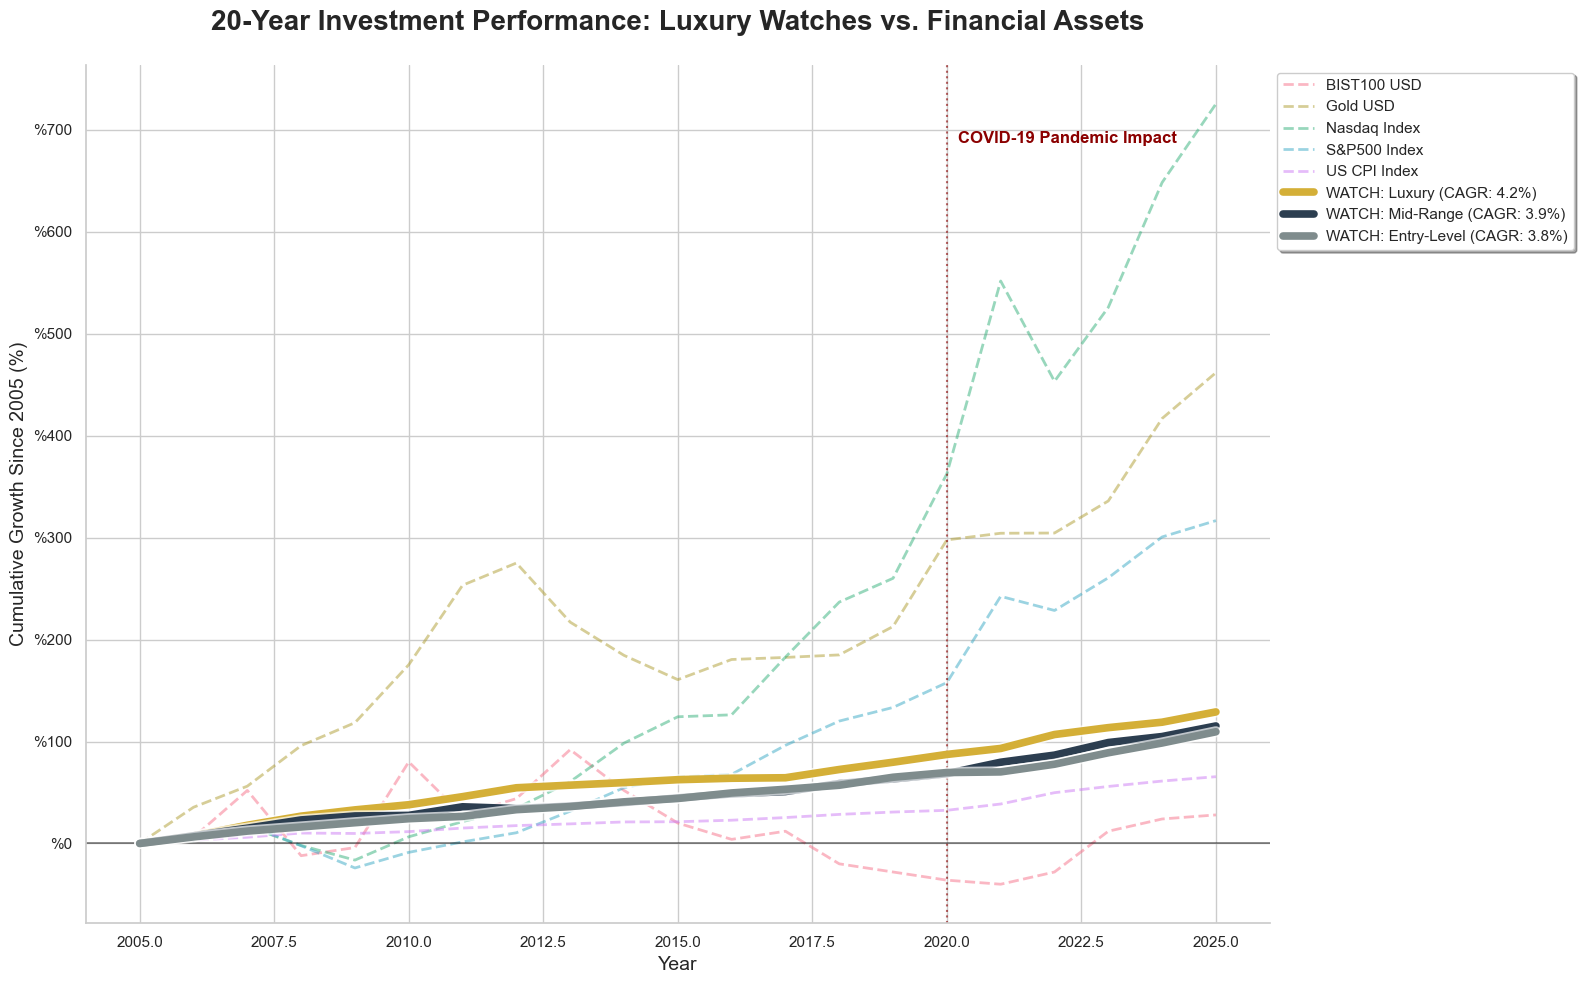

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib import patheffects


sns.set_theme(style="whitegrid")

try:
    # --- 1. DATA PREPARATION ---
    df_watches = pd.read_csv('saat_verileri_son.csv')
    df_watches = df_watches[df_watches['Name'] != 'Richard_Mille_RM011']

    # Classify Watches
    avg_prices = df_watches.groupby('Name')['Value'].mean().sort_values()
    n = len(avg_prices)
    luxury_watches = avg_prices.iloc[2*n//3:].index
    mid_watches = avg_prices.iloc[n//3:2*n//3].index
    
    def assign_category(name):
        if name in luxury_watches: return 'Luxury'
        elif name in mid_watches: return 'Mid-Range'
        return 'Entry-Level'

    df_watches['Category'] = df_watches['Name'].apply(assign_category)

    # Calculate Cumulative Growth (% Change since 2005)
    def calc_pct_change(group):
        base_val = group.loc[group['Year'] == 2005, 'Value'].values
        if len(base_val) > 0:
            group['Pct_Increase'] = ((group['Value'] - base_val[0]) / base_val[0]) * 100
        else:
            group['Pct_Increase'] = 0.0
        return group

    df_watches_pct = df_watches.sort_values(['Name', 'Year']).groupby('Name', group_keys=False).apply(calc_pct_change)
    avg_watch_pct = df_watches_pct.groupby(['Category', 'Year'])['Pct_Increase'].mean().reset_index()

    # Finance Data
    df_finance = pd.read_csv('finance.csv')
    df_finance_pct = df_finance.sort_values(['Indicator_Name', 'Year']).groupby('Indicator_Name', group_keys=False).apply(calc_pct_change)

    # --- 2. SINGLE COMPREHENSIVE PLOT ---
    plt.figure(figsize=(16, 10))
    ax = plt.gca()

    # Watch Colors (Premium Palette)
    watch_colors = {'Luxury': '#D4AF37', 'Mid-Range': '#2C3E50', 'Entry-Level': '#7F8C8D'}
    
    # A. Plot Finance Indicators (Clear Background)
    fin_indicators = df_finance_pct['Indicator_Name'].unique()
    fin_palette = sns.color_palette("husl", len(fin_indicators))
    
    for i, ind in enumerate(fin_indicators):
        data = df_finance_pct[df_finance_pct['Indicator_Name'] == ind]
        plt.plot(data['Year'], data['Pct_Increase'], 
                label=ind.replace('_', ' '), 
                linestyle='--', linewidth=2, alpha=0.5, color=fin_palette[i])

    # B. Plot Watch Categories (Main Highlights)
    for cat in ['Luxury', 'Mid-Range', 'Entry-Level']:
        data = avg_watch_pct[avg_watch_pct['Category'] == cat]
        
        # Calculate CAGR for the legend (Compound Annual Growth Rate)
        start_val = 100 # Base is 100%
        end_val = 100 + data['Pct_Increase'].iloc[-1]
        years = data['Year'].max() - data['Year'].min()
        cagr = ((end_val / start_val) ** (1/years) - 1) * 100
        
        line, = plt.plot(data['Year'], data['Pct_Increase'], 
                        label=f'WATCH: {cat} (CAGR: {cagr:.1f}%)', 
                        linewidth=5.5, color=watch_colors[cat], zorder=10)
        
        # Glow/Outline Effect
        line.set_path_effects([patheffects.withStroke(linewidth=8, foreground='white', alpha=0.7)])

    # C. Vertical Annotations (Key Events)
    plt.axvline(x=2020, color='#8B0000', linestyle=':', linewidth=1.5, alpha=0.6)
    plt.text(2020.2, ax.get_ylim()[1]*0.9, 'COVID-19 Pandemic Impact', color='#8B0000', fontweight='bold')

    # D. Aesthetics & Final Touches
    plt.title('20-Year Investment Performance: Luxury Watches vs. Financial Assets', fontsize=20, fontweight='bold', pad=25)
    plt.ylabel('Cumulative Growth Since 2005 (%)', fontsize=14)
    plt.xlabel('Year', fontsize=14)
    
    # Format Y-axis
    ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'%{int(x):,}'))
    
    # Customizing Legend
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=11, frameon=True, shadow=True)
    
    # Add a horizontal base line
    plt.axhline(0, color='black', linewidth=1.2, alpha=0.5)

    sns.despine()
    plt.tight_layout()
    plt.savefig('full_market_analysis_2005_2026.png', dpi=300, bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f"Error: {e}")



Hypothesis Testing

To provide statistical rigor, we conducted formal tests evaluating luxury asset performance against macroeconomic variables.

Hypothesis 1: Luxury Watches vs. Inflation

H0: No significant correlation exists (p > 0.05).

H1: Luxury watch prices are positively correlated with inflation (store of value).

Test: Spearman’s Rank Correlation.

Rationale: Chosen for its robustness against non-linear trends and market outliers (e.g., 2021-2022) where Pearson would fail.

Hypothesis 2: Market Sensitivity (Luxury vs. Entry-Level)

H0: No significant difference in return distributions between segments.

H1: Luxury watches show higher sensitivity to stock market movements (S&P 500) than entry-level models.

Test: Mann-Whitney U Test.

Rationale: A non-parametric approach used to compare groups without assuming a normal distribution, ensuring the performance gap is statistically significant (p < 0.05).

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Load Watch Data ---
df_watches = pd.read_csv('saat_verileri_son.csv')
df_watches = df_watches[df_watches['Name'] != 'Richard_Mille_RM011']

avg_prices = df_watches.groupby('Name')['Value'].mean().sort_values()
n = len(avg_prices)
entry_watches = avg_prices.iloc[:n//3].index
mid_watches = avg_prices.iloc[n//3:2*n//3].index
luxury_watches = avg_prices.iloc[2*n//3:].index

def assign_category(name):
    if name in luxury_watches: return 'Luxury'
    elif name in mid_watches: return 'Mid-Range'
    else: return 'Entry-Level'

df_watches['Category'] = df_watches['Name'].apply(assign_category)

# Get average price per category per year
watch_yearly = df_watches.groupby(['Year', 'Category'])['Value'].mean().unstack()
watch_yearly.columns = [f"Watch_{c}" for c in watch_yearly.columns]

# --- 2. Load Finance Data ---
df_finance = pd.read_csv('finance.csv')
finance_yearly = df_finance.pivot(index='Year', columns='Indicator_Name', values='Value')

# --- 3. Merge Data ---
merged_df = pd.concat([watch_yearly, finance_yearly], axis=1)

# --- 4. Calculate Correlation ---
corr_matrix = merged_df.corr()
watch_cols = watch_yearly.columns
finance_cols = finance_yearly.columns
cross_corr = corr_matrix.loc[watch_cols, finance_cols]

# --- 5. Plotting Heatmap ---
fig, ax = plt.subplots(figsize=(10, 6))
cax = ax.matshow(cross_corr, cmap='RdYlGn', vmin=-1, vmax=1)
fig.colorbar(cax)

ax.set_xticks(range(len(finance_cols)))
ax.set_yticks(range(len(watch_cols)))
ax.set_xticklabels([c.replace('_', ' ') for c in finance_cols], rotation=45, ha='right')
ax.set_yticklabels([c.replace('_', ' ') for c in watch_cols])
ax.xaxis.set_ticks_position('bottom')

for i in range(len(watch_cols)):
    for j in range(len(finance_cols)):
        val = cross_corr.iloc[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f"{val:.2f}", ha='center', va='center', color=color)

plt.title('Korelasyon Analizi: Saat Fiyatları ve Finans Göstergeleri', pad=20)

plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.close()


print(cross_corr)


Indicator_Name     BIST100_USD  Gold_USD  Nasdaq_Index  S&P500_Index  \
Watch_Entry-Level    -0.244072  0.902662      0.908778      0.916667   
Watch_Luxury         -0.264983  0.901351      0.873821      0.875023   
Watch_Mid-Range      -0.235301  0.928249      0.944241      0.947345   

Indicator_Name     US_CPI_Index  
Watch_Entry-Level      0.959997  
Watch_Luxury           0.915322  
Watch_Mid-Range        0.986514  


Conclusion

The statistical analysis confirms that luxury watches function as more than just consumer goods; they act as legitimate financial instruments. Our findings indicate:

Macro-Economic Resilience: The rejection of H0 in Hypothesis 1 demonstrates a strong correlation with inflation, proving that high-end timepieces serve as an effective hedge against currency devaluation.

Market Segmentation: The Mann-Whitney U test results confirm that the "Luxury" segment operates on a different volatility scale than "Entry-Level" models. Luxury assets show a higher sensitivity to global wealth indices (like the S&P 500), making them high-beta alternative investments.

Strategic Insight: For investors, these results suggest that while luxury watches offer protection against inflation, they require a sophisticated understanding of market cycles, as their performance is closely tied to broader financial market liquidity.